# Intro the the Allen Brain Observatory Visual Coding Ophys Dataset.
This notebook demonstrates how to access and visualize data in the dataset. So far in our tutorials, we've been accesssing data for you. In case you want to access different parts of the dataset for your projects, this tutorial shows how to do that.

<a href="https://colab.research.google.com/github/AllenSWDB/TReND-CaMinA/blob/main/notebooks/Kenya26/03-04-AllenTutorial/Session_4_Data_Access.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()

Standard Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Allen Brain Observatory set up
This instantiates the tools in the Allen SDK that allow us to access the Brain Observatory data.

The main entry point is the `BrainObservatoryCache` class. This class is responsible for accessing any data or metadata.

We begin by importing the `BrainObservatoryCache` class and instantiating it, pointing it to our manifest file.

`manifest_file` is a path to the where the manifest file is located. This needs to reflect where you are storing and accessing the data. Here, we are pointing it to the data on the S3 bucket.

In [2]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [3]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"

    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "allen-brain-observatory","visual-coding-2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

The first thing we do when setting things up is instantiate the Brain Observatory Cache. This is the cache of all the data in the dataset. There are a number of functions that use this cache to access the data and their metadata.

### Querying from the Brain Observatory Cache

The Brain Observatory Cache enables us to see the dimensions of the dataset.

Let's take a look at the available **areas**, **cre lines**, **depths**, and **stimuli** available in the Brain Observatory dataset. These parameters are valuable when selecting data to work with.



We refer to brain areas as "targeted structures". Use `get_all_targeted_structures` to find a list of all the brain areas we imaged from.


In [14]:
# list of all targeted areas
transgenic=boc.get_all_targeted_structures()

We used 14 trangenic lines. The lines are a combination of a Cre driver as well as a reporter. All of our reporters are GCaMP6, but we have different Cre drivers that drive the expression of GCaMP in specificall cell types.

In [ ]:
# list of all cre driver lines
boc.get_all_cre_lines()

['Cux2-CreERT2',
 'Emx1-IRES-Cre',
 'Fezf2-CreER',
 'Nr5a1-Cre',
 'Ntsr1-Cre_GN220',
 'Pvalb-IRES-Cre',
 'Rbp4-Cre_KL100',
 'Rorb-IRES2-Cre',
 'Scnn1a-Tg3-Cre',
 'Slc17a7-IRES2-Cre',
 'Sst-IRES-Cre',
 'Tlx3-Cre_PL56',
 'Vip-IRES-Cre']

We imaged different cell types in different cortical layers, and the imaging depth is one handle we have on the layer identity. But, it's very noisy. E.g. is an imaging depht of 285 different from 275? Not really.

Layers can be best examined using layer specific cell types, but if using the imaging depths, the following is how we assign them to layers.


*   Layer 2/3: <200
*   Layer 4: 200-300
*   Layer 5: 300-500
*   Layer 6: >500



In [5]:
# list of all imaging depths
boc.get_all_imaging_depths()

[175,
 185,
 195,
 200,
 205,
 225,
 250,
 265,
 275,
 276,
 285,
 300,
 320,
 325,
 335,
 350,
 365,
 375,
 390,
 400,
 550,
 570,
 625]

Lastly, we used a variety of stimuli to loook at the visual responses. Different stimuli were used in different sessions. This is described more in a bit. For now, let's get a list of all the stimuli that we used.

In [6]:
# list of all stimuli
boc.get_all_stimuli()

['drifting_gratings',
 'locally_sparse_noise',
 'locally_sparse_noise_4deg',
 'locally_sparse_noise_8deg',
 'natural_movie_one',
 'natural_movie_three',
 'natural_movie_two',
 'natural_scenes',
 'spontaneous',
 'static_gratings']

### Finding Experiment containers in the Brain Observatory Cache
The `experiment container` describes a set of 3 `sessions` performed for the same field of view (ie. same targeted area and imaging depth in the same mouse that targets the same set of neurons). Each experiment container has a unique ID number.

!['Diagram of containers'](http://alleninstitute.github.io/AllenSDK/_static/container_session_layout.png)

We can get a list of all the experiment containers in the dataset. Let's look at this.

In [7]:
containers = boc.get_experiment_containers()

How many containers are in this dataset?

In [8]:
len(containers)

456

Let's look at what information we have about these containers

In [9]:
pd.DataFrame(containers)

,id,imaging_depth,targeted_structure,cre_line,reporter_line,donor_name,specimen_name,tags,failed
0,660492886,275,VISal,Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),306500,Sst-IRES-Cre;Ai148(CAM)-306500,[],False
1,651773425,375,VISl,Fezf2-CreER,Ai148(TIT2L-GC6f-ICL-tTA2),351315,Fezf2-CreER;Ai148-351315,[],False
2,546328009,350,VISal,Nr5a1-Cre,Ai93(TITL-GCaMP6f),261969,Nr5a1-Cre;Camk2a-tTA;Ai93-261969,[],False
3,661437138,175,VISp,Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),365251,Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93-365251,[],False
4,511510911,350,VISp,Scnn1a-Tg3-Cre,Ai93(TITL-GCaMP6f),230570,Scnn1a-Tg3-Cre;Camk2a-tTA;Ai93-230570,[],False
...,...,...,...,...,...,...,...,...,...
451,591392164,175,VISrl,Cux2-CreERT2,Ai93(TITL-GCaMP6f),308148,Cux2-CreERT2;Camk2a-tTA;Ai93-308148,[],False
452,572607996,375,VISal,Rbp4-Cre_KL100,Ai93(TITL-GCaMP6f),291465,Rbp4-Cre_KL100;Camk2a-tTA;Ai93-291465,[],False
453,527676429,275,VISp,Emx1-IRES-Cre,Ai93(TITL-GCaMP6f),237706,Emx1-IRES-Cre;Camk2a-tTA;Ai93-237706,[Epileptiform Events],False
454,580043437,275,VISp,Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),297504,Sst-IRES-Cre;Ai148(CAM)-297504,[],False


And now let's find all the "sessions" (These are called "ophys experiments"):

In [10]:
exps = boc.get_ophys_experiments()

How many sessions are there? Is this how many you expect?

In [11]:
len(exps)

1368

And what information do we have about each session:

In [ ]:

pd.DataFrame(exps)

,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,566752133,175,VISl,Emx1-IRES-Cre,Ai93(TITL-GCaMP6f),116,564425775,three_session_C2,283147,Emx1-IRES-Cre;Camk2a-tTA;Ai93-283147,True
1,653123586,275,VISl,Rorb-IRES2-Cre,Ai93(TITL-GCaMP6f),111,653123584,three_session_C2,352471,Rorb-IRES2-Cre;Camk2a-tTA;Ai93-352471,True
2,577225417,275,VISl,Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),105,575772104,three_session_C2,296710,Vip-IRES-Cre;Ai148-296710,False
3,556353209,375,VISam,Rbp4-Cre_KL100,Ai93(TITL-GCaMP6f),101,555327033,three_session_A,271750,Rbp4-Cre;Camk2a-tTA;Ai93-271750,True
4,510390912,275,VISal,Rorb-IRES2-Cre,Ai93(TITL-GCaMP6f),80,511500480,three_session_A,232623,Rorb-IRES2-Cre;Camk2a-tTA;Ai93-232623,False
...,...,...,...,...,...,...,...,...,...,...,...
1363,577820172,275,VISam,Rorb-IRES2-Cre,Ai93(TITL-GCaMP6f),110,576411244,three_session_B,295995,Rorb-IRES2-Cre;Camk2a-tTA;Ai93-295995,False
1364,648389302,275,VISp,Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),108,647155120,three_session_B,347751,Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93-347751,False
1365,510517609,375,VISpm,Rbp4-Cre_KL100,Ai93(TITL-GCaMP6f),75,511511006,three_session_B,233442,Rbp4-Cre;Camk2a-tTA;Ai93-233442,False
1366,547560448,350,VISal,Nr5a1-Cre,Ai93(TITL-GCaMP6f),107,546328009,three_session_C2,261969,Nr5a1-Cre;Camk2a-tTA;Ai93-261969,False


How is this different from what we have for the containers? Why is it different?

# Finding Experiment Containers of Interest

When you are working with the data, you'll want to select data using some of the parameters that we just explored. The boc enables you to select sessions using those parameters.

We may be interested in a specific visual area and Cre line. Let's choose a visual area and Cre line from the lists above.

In [12]:
visual_area = 'VISp'
cre_line ='Cux2-CreERT2'

In [18]:
visual_area2 = 'VISal'
cre_line2 ='Sst-IRES-Cre'

You can pass these as parameters to the `get_experiment_container` function we saw before.

In [13]:
? boc.get_experiment_containers

In [ ]:

containers = boc.get_experiment_containers(cre_lines=[cre_line], targeted_structures=[visual_area])

How many experiment containers did you find?

In [26]:
containers2

[]

In [22]:
len(containers2)

0

In [ ]:
len(containers)

16

In [ ]:
pd.DataFrame(containers)

,id,imaging_depth,targeted_structure,cre_line,reporter_line,donor_name,specimen_name,tags,failed
0,511510736,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,[],False
1,511510855,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),229106,Cux2-CreERT2;Camk2a-tTA;Ai93-229106,[],False
2,511509529,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,[],False
3,511507650,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,[],False
4,511510699,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),225037,Cux2-CreERT2;Camk2a-tTA;Ai93-225037,[],False
5,702934962,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),382421,Cux2-CreERT2;Camk2a-tTA;Ai93-382421,[],False
6,645413757,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),348262,Cux2-CreERT2;Camk2a-tTA;Ai93-348262,[],False
7,659767480,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),360565,Cux2-CreERT2;Camk2a-tTA;Ai93-360565,[],False
8,511510650,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),222425,Cux2-CreERT2;Camk2a-tTA;Ai93-222425,[],False
9,712178509,275,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),390323,Cux2-CreERT2;Camk2a-tTA;Ai93-390323,[],False


Exercise: try selecting containers with other parameters

Now let's look at one of these experiment containers:

In [27]:
experiment_container_id = 511510736

Let's get all of the sessions for this container.

In [28]:
?boc.get_ophys_experiments

In [29]:
exps = boc.get_ophys_experiments(experiment_container_ids=[experiment_container_id])
pd.DataFrame(exps)

,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,501704220,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),104,511510736,three_session_A,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True
1,501559087,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),103,511510736,three_session_B,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True
2,501474098,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),102,511510736,three_session_C,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True


Let's find the session from this container that used the `natural_scenes` stimulus.

In [32]:
exps = boc.get_ophys_experiments(experiment_container_ids=[experiment_container_id], stimuli=['natural_scenes'])

pd.DataFrame(exps)

,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,501559087,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),103,511510736,three_session_B,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True


Each session has a unique ID, and we can use that ID to access the data for this session.

In [33]:
session_id = boc.get_ophys_experiments(experiment_container_ids=[experiment_container_id],
                                       stimuli=['natural_scenes'])[0]['id']
print(session_id)

501559087


This concludes the section on querying the brain observatory cache for searching for experiments. We will now look into how we can find information about specific Sessions (Ophys Experiments)

# Ophys Experiment data
A single imaging session is stored in an NWB File. This section shows us how to access everything in the NWB file for a single imaging session. An ophys session contains the following:


1.   Maximum Projection of the Ophys Session
2.   ROI masks for cells
3.   DF/F Traces
4.   Stimulus Epochs
5.   Running Speed
6.   Stimulus Table
7.   Stimulus Template



In [34]:
?boc.get_ophys_experiment_data

In [35]:
data_set = boc.get_ophys_experiment_data(ophys_experiment_id=session_id)
data_set

We can use this `data_set` object to access all the pieces of data for the session. Let's take a look.

# Maximum projection
This is the projection of the full motion corrected movie. It shows all of the neurons imaged during the session.

In [36]:
max_projection = data_set.get_max_projection()
max_projection.shape

(512, 512)

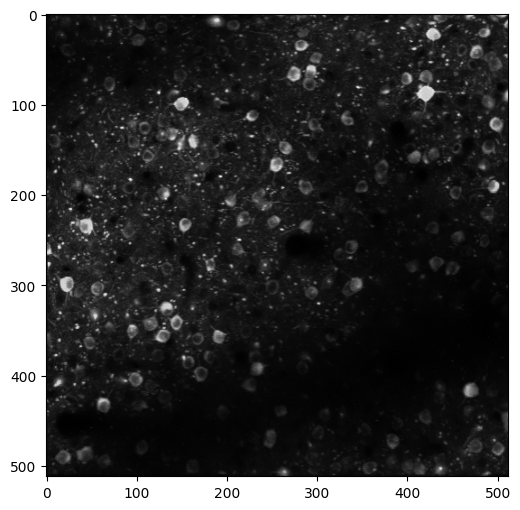

In [37]:
fig = plt.figure(figsize=(6,6))
plt.imshow(max_projection, cmap='gray')

# ROI Masks
These are all of the segmented masks for cell bodies in this experiment.

In [38]:
rois = data_set.get_roi_mask_array()
rois.shape

(174, 512, 512)

Look at the dimensions of the mask. There is one image per cell.

In [39]:
print(rois.shape)
print("Number of cells:", rois.shape[0])

(174, 512, 512)
Number of cells: 174


Let's look at a mask for one cell:

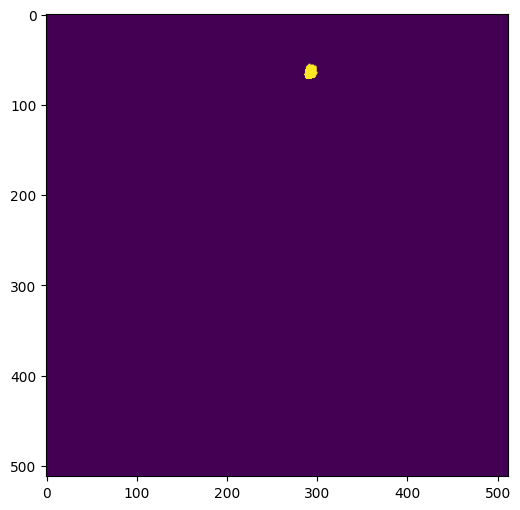

In [40]:
plt.figure(figsize=(6,6))
plt.imshow(rois[0,:,:])


To look at all cells, instead we can sum them up:

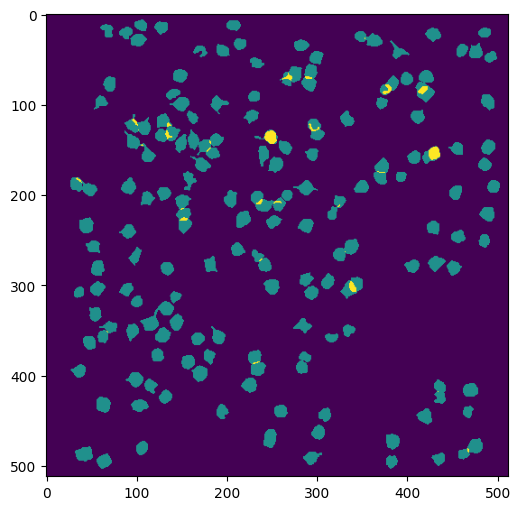

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(rois.sum(axis=0))

# DF/F Traces
There are a number of accessible traces for all these 174 cells in the NWB file, including raw fluorescence, neuropil corrected traces, demixed traces, and DF/F traces. There are also extracted events available.
In this tutorial we will use DF/F to examine neural activity. The function to get this returns a tuple, including the timestamps and the dff traces.

In [43]:
ts, dff = data_set.get_dff_traces() # we have one trace per cell and there are 174 cells

Let's look at dff and ts

In [42]:
dff

array([[0.20965546, 0.1863484 , 0.19161665, ..., 0.09774321, 0.11352707,
        0.13668476],
       [0.26439214, 0.20498341, 0.07929777, ..., 0.13164276, 0.1731477 ,
        0.04964808],
       [0.20654976, 0.24736755, 0.17095044, ..., 0.25507164, 0.22133712,
        0.33088112],
       ...,
       [0.14863771, 0.14606293, 0.17870486, ..., 0.11028486, 0.0950325 ,
        0.14673813],
       [0.20627266, 0.15208568, 0.07461747, ..., 0.17313483, 0.08793492,
        0.2939642 ],
       [0.23693745, 0.25396946, 0.0472189 , ..., 0.15417989, 0.16579214,
        0.1795123 ]], dtype=float32)

In [ ]:
dff.shape

(174, 113888)

Notice that this function returns an array that contains the dff trace for all of the recorded neurons in this session.

In [ ]:
ts.shape

(113888,)

Let's plot the activity of one neuron:

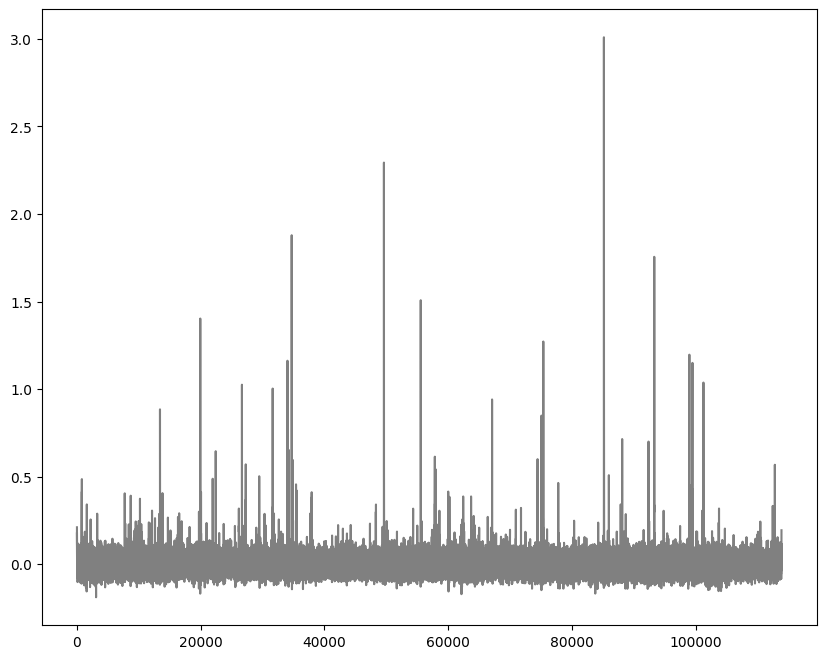

In [46]:
fig = plt.figure(figsize=(10,8))
plt.plot(dff[15,:], color='gray')

Let's plot the activity of the first 50 neurons from this session.

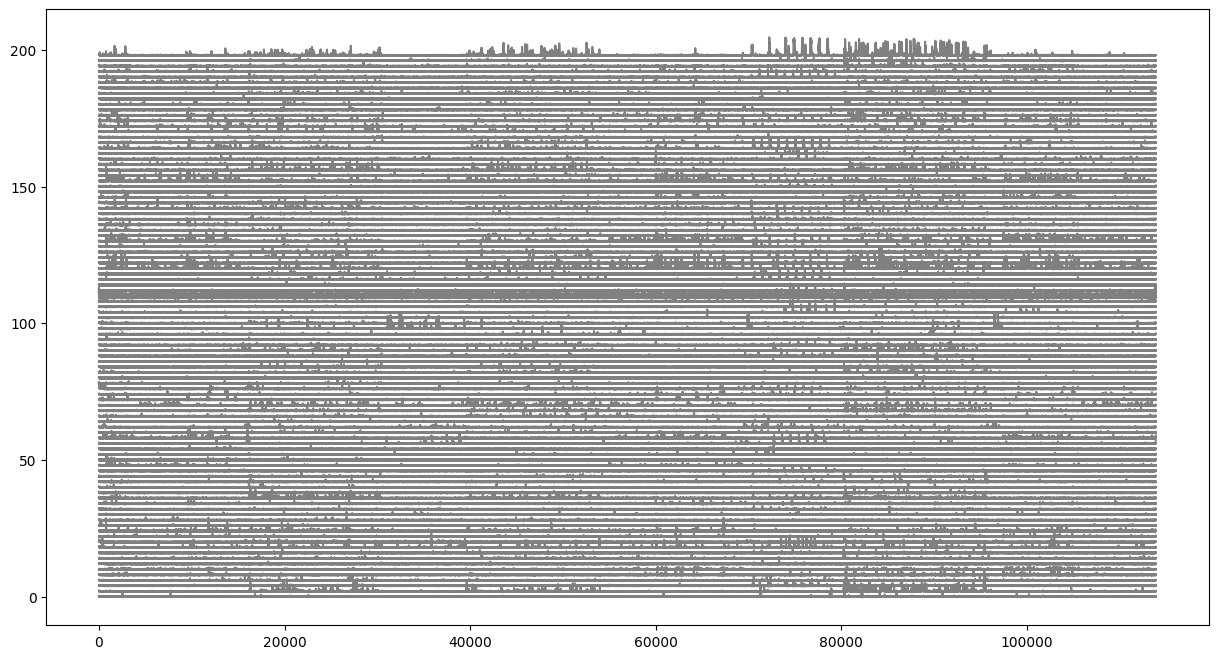

In [48]:
fig = plt.figure(figsize=(15,8))
for i in range(100):
    #plt.plot(dff[i,:])
    plt.plot(dff[i,:]+(i*2), color='gray')

# Stimulus epochs
Several stimuli are shown during each imaging session, interleaved with each other in epochs of 5-20 minutes. The stimulus epoch table provides information of these interleaved stimulus epochs. (epoch means a period of time)

In [49]:
stim_epoch = data_set.get_stimulus_epoch_table()
stim_epoch

,stimulus,start,end
0,static_gratings,747,15196
1,natural_scenes,16100,30551
2,spontaneous,30701,39581
3,natural_scenes,39582,54050
4,static_gratings,54953,69403
5,natural_movie_one,70307,79338
6,natural_scenes,80241,96126
7,static_gratings,97406,113662


Let's add the stimulus epoch information to the plot of neural activity.

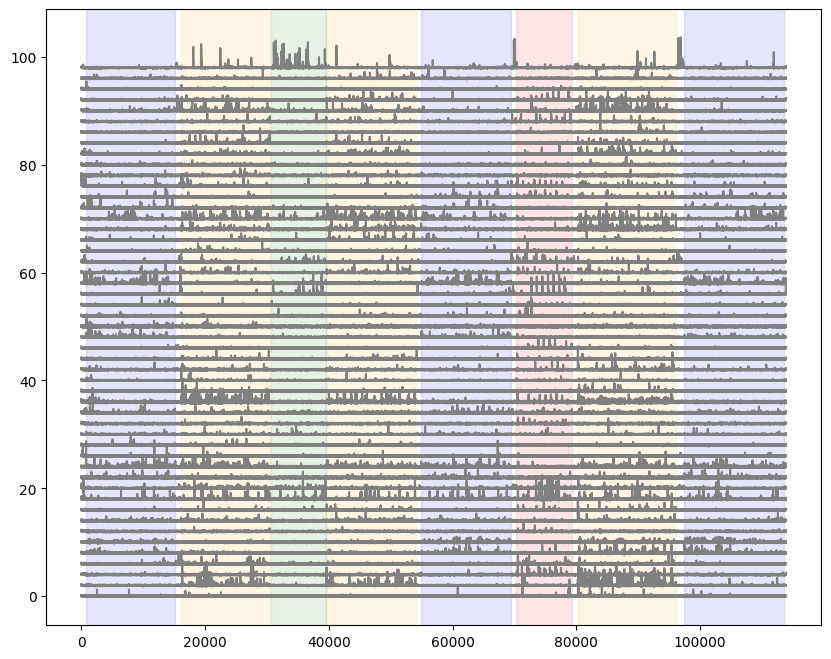

In [50]:
#plot activity of first 50 neurons
fig = plt.figure(figsize=(10,8))
for i in range(50):
    plt.plot(dff[i,:]+(i*2), color='gray')

#for each stimulus, shade the plot when the stimulus is presented
colors = ['blue','orange','green','red']
for c,stim_name in enumerate(stim_epoch.stimulus.unique()):
    stim = stim_epoch[stim_epoch.stimulus==stim_name]
    for j in range(len(stim)):
        plt.axvspan(xmin=stim.start.iloc[j], xmax=stim.end.iloc[j], color=colors[c], alpha=0.1)


# Running speed
We recorded the running speed of the animal on the rotating disk during the entire session. We can access this using `get_running_speed`. This returns a tuple of the running speed and the timestamps, but for some reason the timestamps come second here. Note the running speed is in units of cm/s.

Text(0, 0.5, 'Running speed (cm/s)')

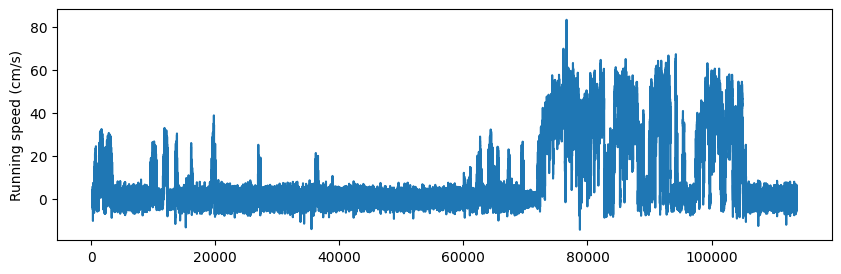

In [51]:
running, tsd = data_set.get_running_speed()

fig = plt.figure(figsize=(10,3))
plt.plot(running)
plt.ylabel("Running speed (cm/s)")

Let's add the running speed to our plot of neural activity and stimulus epochs.

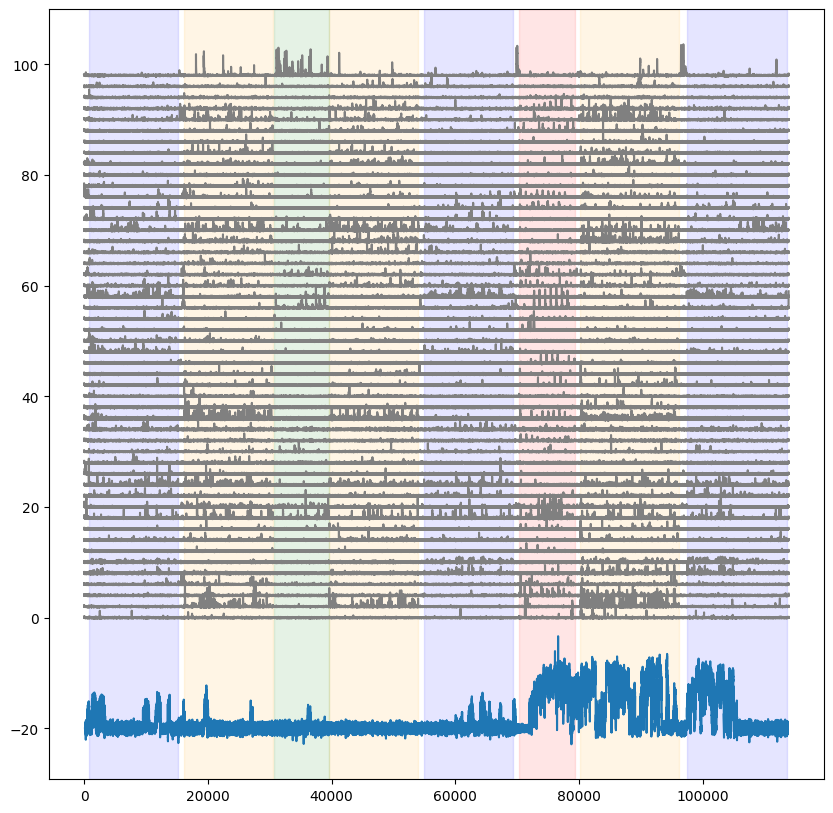

In [52]:
#plot activity of first 50 neurons
fig = plt.figure(figsize=(10,10))
for i in range(50):
    plt.plot(dff[i,:]+(i*2), color='gray')

#plot the running speed (scaled and offset to fit)
plt.plot((0.2*running)-20)

#for each stimulus, shade the plot when the stimulus is presented
colors = ['blue','orange','green','red']
for c,stim_name in enumerate(stim_epoch.stimulus.unique()):
    stim = stim_epoch[stim_epoch.stimulus==stim_name]
    for j in range(len(stim)):
        plt.axvspan(xmin=stim.start.iloc[j], xmax=stim.end.iloc[j], color=colors[c], alpha=0.1)


Let's look at a few individual neurons.

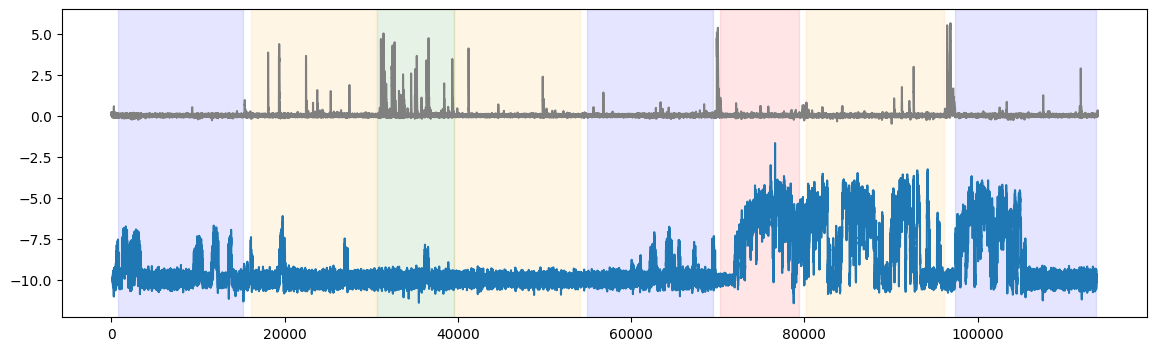

In [53]:
fig = plt.figure(figsize=(14,4))

plt.plot(dff[49,:], color='gray')
plt.plot((0.1*running)-10)

#for each stimulus, shade the plot when the stimulus is presented
colors = ['blue','orange','green','red']
for c,stim_name in enumerate(stim_epoch.stimulus.unique()):
    stim = stim_epoch[stim_epoch.stimulus==stim_name]
    for j in range(len(stim)):
        plt.axvspan(xmin=stim.start.iloc[j], xmax=stim.end.iloc[j], color=colors[c], alpha=0.1)


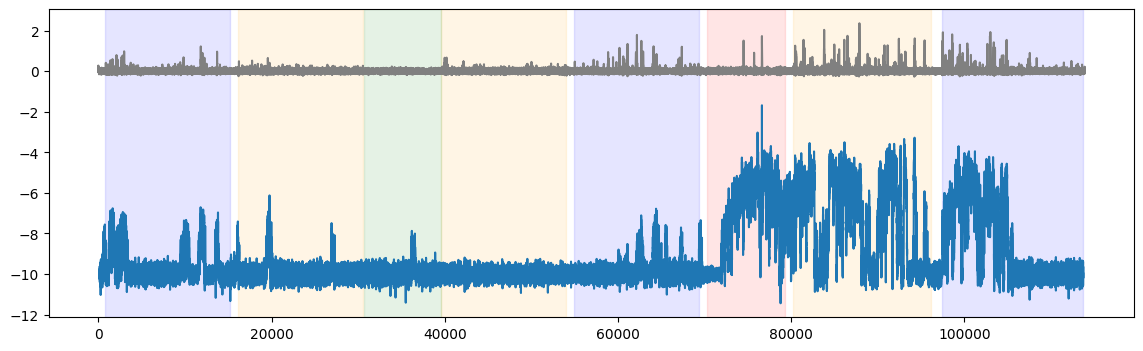

In [54]:
fig = plt.figure(figsize=(14,4))

plt.plot(dff[4,:], color='gray')
plt.plot((0.1*running)-10)

#for each stimulus, shade the plot when the stimulus is presented
colors = ['blue','orange','green','red']
for c,stim_name in enumerate(stim_epoch.stimulus.unique()):
    stim = stim_epoch[stim_epoch.stimulus==stim_name]
    for j in range(len(stim)):
        plt.axvspan(xmin=stim.start.iloc[j], xmax=stim.end.iloc[j], color=colors[c], alpha=0.1)

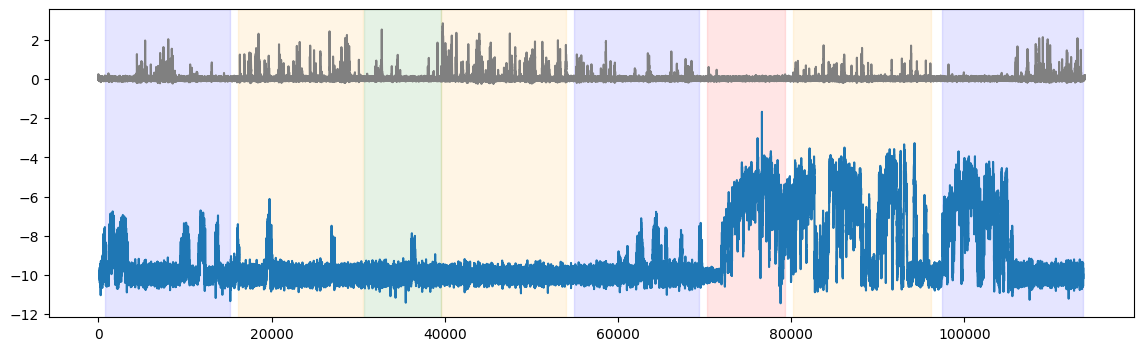

In [55]:
fig = plt.figure(figsize=(14,4))

plt.plot(dff[35,:], color='gray')
plt.plot((0.1*running)-10)

#for each stimulus, shade the plot when the stimulus is presented
colors = ['blue','orange','green','red']
for c,stim_name in enumerate(stim_epoch.stimulus.unique()):
    stim = stim_epoch[stim_epoch.stimulus==stim_name]
    for j in range(len(stim)):
        plt.axvspan(xmin=stim.start.iloc[j], xmax=stim.end.iloc[j], color=colors[c], alpha=0.1) #anticorrelated to the running

# Stimulus Table
The stimulus epoch shows you the stimulus on a coarse scale, but for each stimulus there is a stimulus table with information about the condition and timing of each trial. We've already seen this for the drifting grating stimulus. Let's look at a different stimulus here.

In [60]:
natural_scene_table = data_set.get_stimulus_table('natural_scenes')
natural_scene_table.head(n=10)


,frame,start,end
0,81,16100,16107
1,33,16108,16115
2,76,16115,16122
3,13,16123,16130
4,56,16130,16137
5,30,16138,16145
6,44,16145,16152
7,93,16153,16160
8,65,16160,16167
9,60,16168,16175


In [59]:
natural_scene_table = data_set.get_stimulus_table('static_gratings')
natural_scene_table.head(n=10)

,orientation,spatial_frequency,phase,start,end
0,90.0,0.04,0.50,747,754
1,150.0,0.04,0.50,754,761
2,30.0,0.02,0.00,762,769
3,0.0,0.32,0.50,769,776
4,150.0,0.16,0.75,777,784
5,150.0,0.08,0.25,784,791
6,90.0,0.32,0.50,792,799
7,60.0,0.04,0.25,799,806
8,30.0,0.08,0.75,807,814
9,90.0,0.32,0.50,814,821


# Stimulus Template
The images and movies presented during the session area also included in the NWB file as the stimulus template. Stimuli that are generated programmatically (eg. drifting and static gratings) do not have a stimulus template. There are tools in the SDK to recreate these stimuli.

In [61]:
natural_scene_template = data_set.get_stimulus_template('natural_scenes')

In [62]:
natural_scene_template.shape

(118, 918, 1174)

Let's look at the scene presented in the first trial.

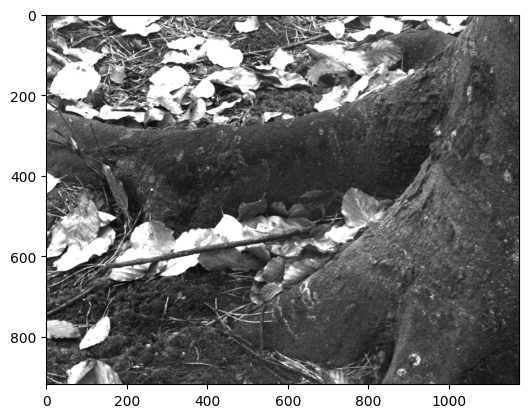

In [73]:
scene_number = natural_scene_table.frame.loc[40]
plt.imshow(natural_scene_template[scene_number,:,:], cmap='grey')

We can add the trials of this image to the plot of neural activity too:

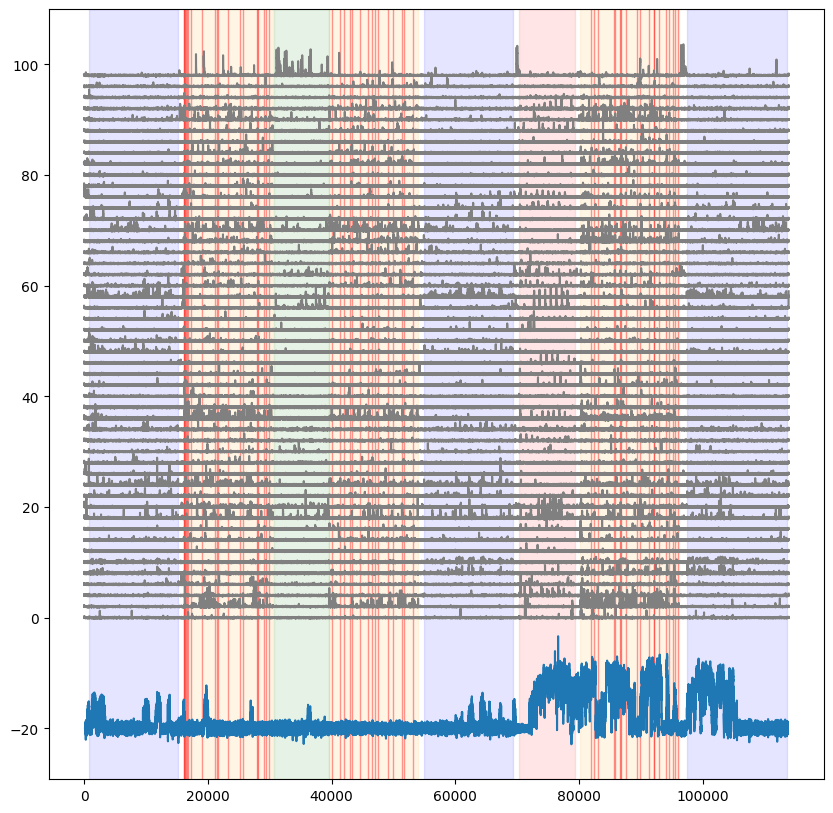

In [69]:
#plot activity of first 50 neurons
fig = plt.figure(figsize=(10,10))
for i in range(50):
    plt.plot(dff[i,:]+(i*2), color='gray')

#plot the running speed (scaled and offset to fit)
plt.plot((0.2*running)-20)

#for each stimulus, shade the plot when the stimulus is presented
colors = ['blue','orange','green','red']
for c,stim_name in enumerate(stim_epoch.stimulus.unique()):
    stim = stim_epoch[stim_epoch.stimulus==stim_name]
    for j in range(len(stim)):
        plt.axvspan(xmin=stim.start.iloc[j], xmax=stim.end.iloc[j], color=colors[c], alpha=0.1)

#shade traces with the time of each presentation of the above scene
stim_subset = natural_scene_table[natural_scene_table.frame==scene_number]
for j in range(len(stim_subset)):
    plt.axvspan(xmin=stim_subset.start.iloc[j], xmax=stim_subset.end.iloc[j], color='red', alpha=0.4)

We can zoom in on these trials. We'll look at one neuron's responses to all the trials of one image.

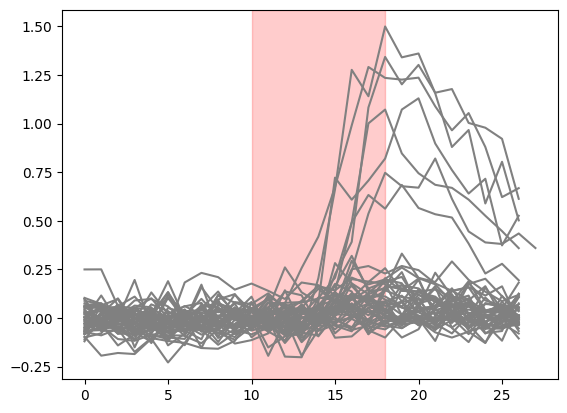

In [74]:
cell_index=19
scene_number=22

stim_subset = natural_scene_table[natural_scene_table.frame==scene_number]

for i in range(len(stim_subset)):
    plt.plot(dff[cell_index,stim_subset.start.iloc[i]-10:stim_subset.end.iloc[i]+10], color='gray')
plt.axvspan(10,18, color='red',alpha=0.2)


#### Specimen IDs

Each cell in the dataset has a unique ID, called the "Specimen ID". Let us find the cell specimen IDS for the cells in this session.


In [ ]:
data_set.get_cell_specimen_ids()

array([517473350, 517473341, 517473313, 517473255, 517471959, 517471769,
       517473059, 517471997, 517472716, 517471919, 517472989, 517472293,
       517473115, 517472454, 517473020, 517472734, 517474366, 587377483,
       517471708, 587377366, 587377223, 517474444, 517474437, 517473105,
       517472300, 517472326, 517472708, 517472215, 517472712, 517472360,
       517472399, 517472197, 517472582, 517472190, 517473926, 587377518,
       517471931, 517472637, 517472416, 517471658, 517472724, 517472684,
       517471664, 587377211, 517473947, 587377064, 517472063, 587377621,
       517473080, 517472553, 517473001, 517474078, 517471794, 517471674,
       517473916, 517471803, 517472592, 517473014, 517474459, 517472241,
       517472720, 517472534, 517472054, 587377662, 517474012, 517474020,
       517473653, 517472007, 517472645, 517472211, 517472677, 517472731,
       517472621, 517472442, 587377204, 517473027, 517472818, 517473304,
       517474121, 517473034, 517472909, 517473624, 

Why is this useful? The cell specimen IDs can help us specify which cells we would like to analyze in any of the traces. Each cell specifmen ID is associated with an "index" of the trace arrays. For example, the first cell above : 517473350 is associated with index "0". You can get this information by using the following command: (Note that this takes a list and outputs a list)


In [ ]:
indices = data_set.get_cell_specimen_indices(cell_specimen_ids = [517474415])
indices

[129]

This means that to find the trace of this cell in the dff array, we would use the index of the cell specimen like this:

In [ ]:
dff_trace = dff[indices[0],:]

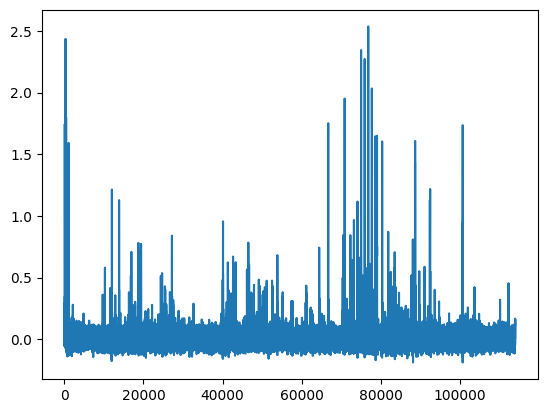

In [ ]:
plt.plot(dff_trace)

The other importance of the cell_specimen_id is that it persists across the sessions in the container. We tried to image the same neurons across three sessions in each container, and after imaging and segementation, we were able to match many neurons across those sessions (though not all!).

In [ ]:
pd.DataFrame(boc.get_ophys_experiments(cell_specimen_ids=[517474415]))

,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,501704220,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),104,511510736,three_session_A,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True
1,501559087,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),103,511510736,three_session_B,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True
2,501474098,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),102,511510736,three_session_C,222426,Cux2-CreERT2;Camk2a-tTA;Ai93-222426,True
